# Descripción del proyecto

Estás trabajando como analista para Zuber, una nueva empresa de viajes compartidos que se está lanzando en Chicago. Tu tarea es encontrar patrones en la información disponible. Quieres comprender las preferencias de los pasajeros y el impacto de los factores externos en los viajes.

Al trabajar con una base de datos, analizarás los datos de los competidores y probarás una hipótesis sobre el impacto del clima en la frecuencia de los viajes.

**Paso 4: Análisis exploratorio de datos (Python)**

Además de los datos que recuperaste en las tareas anteriores te han dado un segundo archivo. Ahora tienes estos dos CSV:

***/datasets/project_sql_result_01.csv***. contiene los siguientes datos:

 - company_name: nombre de la empresa de taxis

 - trips_amount: el número de viajes de cada compañía de taxis el 15 y 16 de noviembre de 2017. 

***/datasets/project_sql_result_04.csv***. contiene los siguientes datos:

 - dropoff_location_name: barrios de Chicago donde finalizaron los viajes

 - average_trips: el promedio de viajes que terminaron en cada barrio en noviembre de 2017.

 Para estos dos datasets ahora necesitas
<div>
4.1. Importar los archivos
<div/>

In [ ]:
# Importación de las librerias y de los archivos csv

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats as st

df_1 = pd.read_csv('/datasets/project_sql_result_01.csv')
df_2 = pd.read_csv('/datasets/project_sql_result_04.csv')


4.2. Estudiar los datos que contienen

In [2]:
# Visualización las 7 primeras filas del contenido de las tablas
display(df_1.head(7))
print()
display(df_2.head(7))

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333


4.3. Asegurarte de que los tipos de datos sean correctos

In [3]:
#Información sobre el tipo de datos que contienen las tablas
display(df_1.info())
print()
display(df_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


None

4.4. Identificar los 10 principales barrios en términos de finalización del recorrido

In [4]:
# Filtro de las paltaformas con mayor promedio de recorridos
gr_top = df_2.groupby('dropoff_location_name')['average_trips'].sum().sort_values(ascending=False)
top_10 =gr_top.head(10)
# Selección de los 10 principales barrios donde finalizó el recorrido
display(top_10)

dropoff_location_name
Loop                  10727.466667
River North            9523.666667
Streeterville          6664.666667
West Loop              5163.666667
O'Hare                 2546.900000
Lake View              2420.966667
Grant Park             2068.533333
Museum Campus          1510.000000
Gold Coast             1364.233333
Sheffield & DePaul     1259.766667
Name: average_trips, dtype: float64

4.5. Hacer gráficos: empresas de taxis y número de viajes, los 10 barrios principales por número de finalizaciones

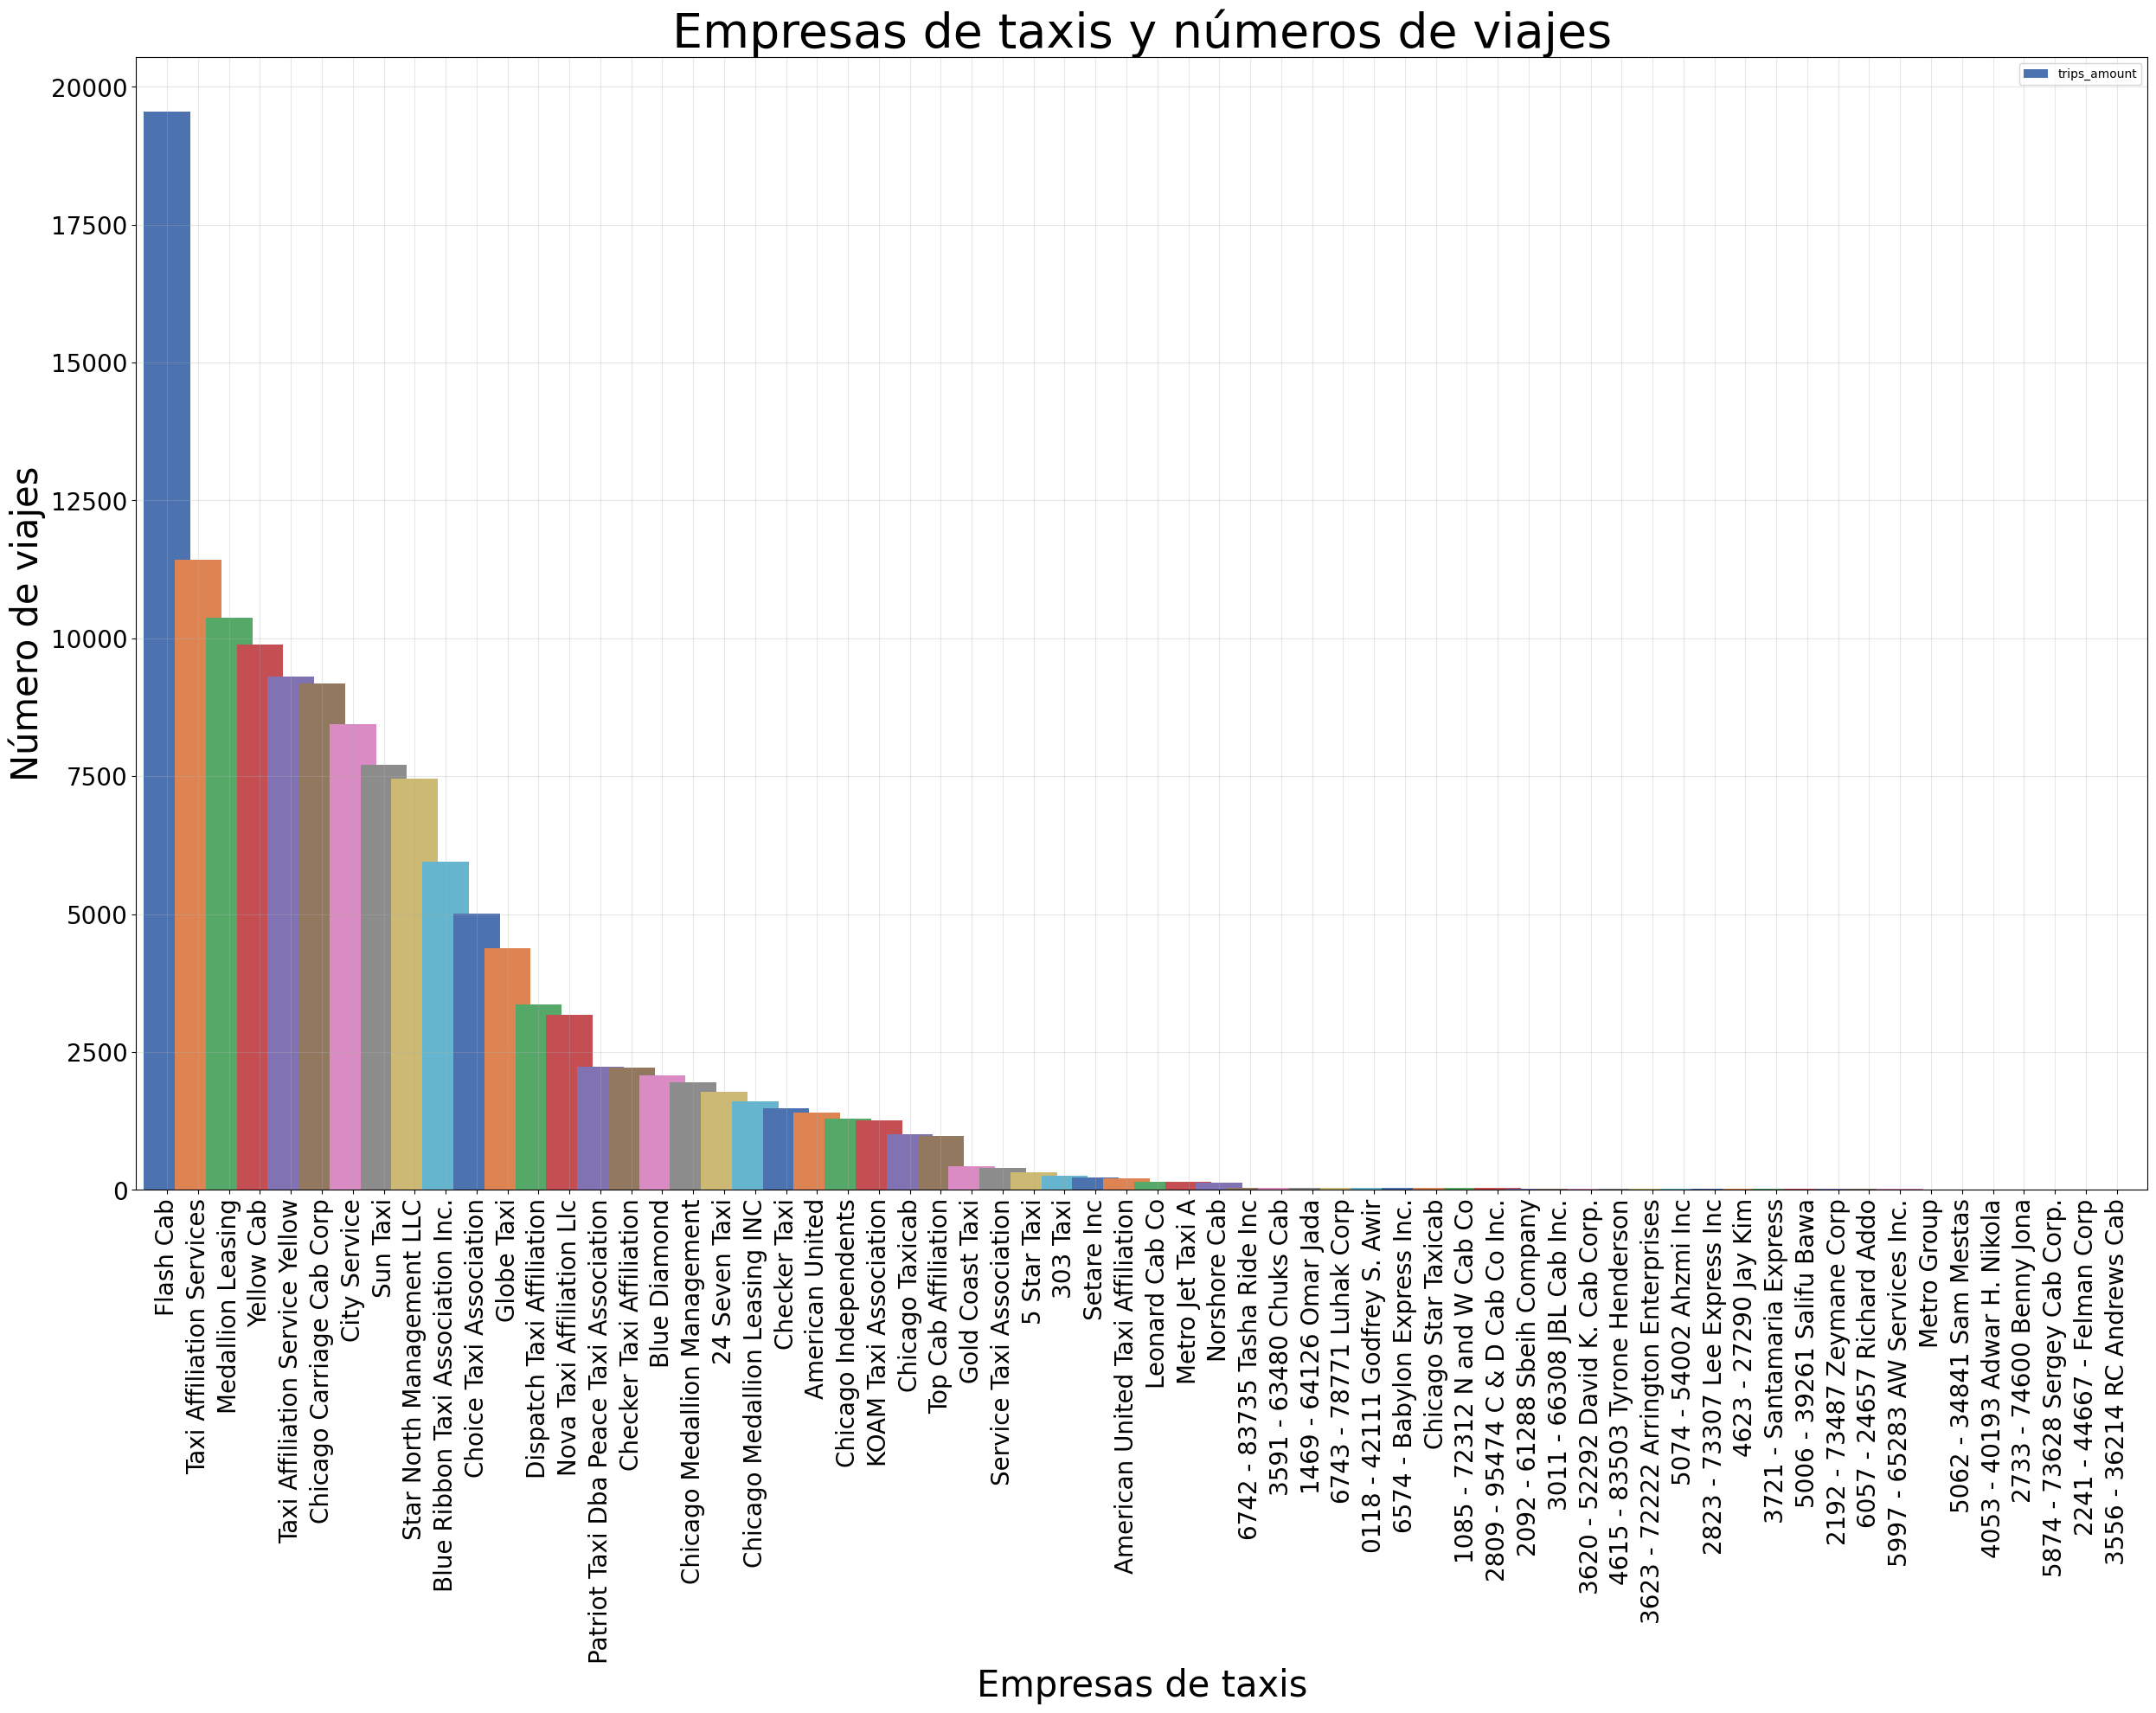

In [5]:
# Gráfico de las empresas de taxis y números de viajes
colors = sns.color_palette('deep', 64)
df_1.plot(x='company_name', y='trips_amount', kind='bar', color=colors, width=1.5, figsize=[30, 17], fontsize=20)
plt.title('Empresas de taxis y números de viajes', fontsize=40)
plt.xlabel('Empresas de taxis', fontsize=30)
plt.ylabel('Número de viajes', fontsize=30)
plt.grid(True, alpha=0.3)
plt.show()

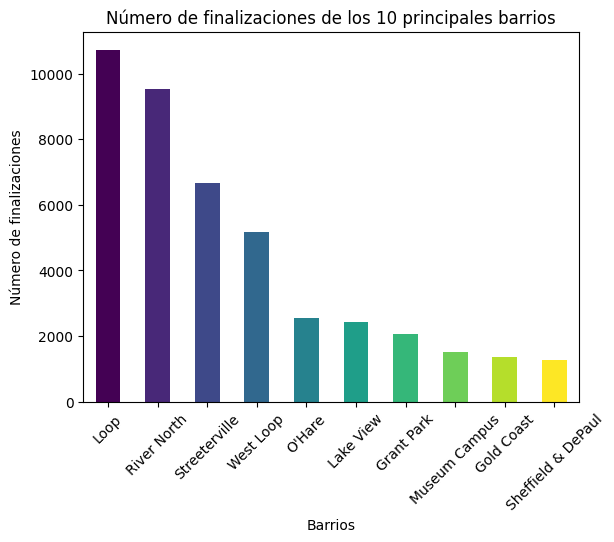

In [6]:
# Gráfico de los 10 barrios principales por número de finalizaciones
colors_1 = plt.cm.viridis(np.linspace(0, 1, len(top_10)))
top_10.plot(x='dropoff_location_name', y='average_trips', kind='bar', color=colors_1, rot=45)

plt.title('Número de finalizaciones de los 10 principales barrios')
plt.xlabel('Barrios')
plt.ylabel('Número de finalizaciones')
plt.show()

4.6. Sacar conclusiones basadas en cada gráfico y explicar los resultados

***Conclusiones:***

* Gráfico Empresas de taxis vs. Número de viajes:
  
   1. Se observa que las 5 empresas con mayores viajes realizados son:
    - Flash Cab (siendo esta por casi el doble de viajes la más popular que la segunda empresa en esta categoría)
    - Taxi Affiliation Services
    - Medallion Leasing
    - Yellow Cab
    - Taxi Affiliation Service Yellow

   2. Las empresas con menos viajes realizados son:
    - 4053 - 40193 Adwar H. Nikola
    - 2733 - 74600 Benny Jona
    - 5874 - 73628 Sergey Cab Corp.
    - 2241 - 44667 - Felman Corp
    - 3556 - 36214 RC Andrews Cab
 
Esto puede presentarse por diferentes razones por ejemplo las compañías más populares pueden contar con mayor catidad de vehiculos, lo que permite que puedan satisfacer mayor cantidad de clientes; pueden presentar un excelente servicio y por ello los usuarios los prefieren tanto; pueden ofrecer más destinos a los usuarios; sus precios son accequibles para los usuarios, pueden ser muchos los motivos por los cuales son preferidas por los usuarios, sin embargo no se puede concluir la razón real por la cual son populares, pues la información con la que se cuenta no permité realizar este analisis para conocer el motivo real de su popularidad.

* Gráfico de los 10 principales barrios en términos de finalización de recorrido

Los barrio con más finalizaciones de recorridos son: Loop, seguido de River North, Streetweville, West Loop y O'Hare. Para el caso de Loop su popularidad puede deberse a que está ubicada en el distrito financiero de Chicago donde se encuentran las sedes del gobierno municipal, por lo que es un lugar con alta concurrencia no solo por las personas que trabajan en este lugar sino por los ciudadanos que requieran de servicios en las diferentes entidades de este lugar. Para el caso de River North en Chicago, es conocida por su animada lista de clubes nocturnos, su lujosa escena comercial y Restaurantes con comida deliciosa, lo que lo hace un lugar muy atractivo tanto para turistas como para locales cuando quieran hacer algo diferente. En conclusión los lugares más populares ofrece cosas atractivas y servicios para las personas que los atraen y son visitados por locales y turistas con frecuencia. 

**Paso 5. Prueba de hipótesis (Python)**

*/datasets/project_sql_result_07.csv* — el resultado de la última consulta. Contiene datos sobre viajes desde el Loop hasta el Aeropuerto Internacional O'Hare. Recuerda, estos son los valores de campo de la tabla:

In [7]:
df_3 = pd.read_csv('/datasets/project_sql_result_07.csv')
display(df_3.head(7))
print()
display(df_3.info())

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
5,2017-11-11 04:00:00,Good,1320.0
6,2017-11-04 16:00:00,Bad,2969.0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


None

**5.1 Prueba la hipótesis:**

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Decide por tu cuenta dónde establecer el nivel de significación (alfa).

*Explica:*

cómo planteaste las hipótesis nula y alternativa
qué criterio usaste para probar las hipótesis y por qué

In [8]:
# Tiempo promedio de viaje desde Loop hasta el Aeropuerto Internacional O'Hare
trip_mean = df_3.groupby(by='weather_conditions').mean()

# Tiempo promedio de viaje los días lluviosos desde Loop hasta el Aeropuerto Internacional O'Hare
trip_mean_wbad = df_3[df_3['weather_conditions'] == 'Bad'].mean()
print(f'El promedio de viaje en segundos para los días llusiosos es:', trip_mean_wbad)
print()

#Prueba de Hipótesis

# Ho: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos
# Ha: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare no cambia los sábados lluviosos

interested_value = trip_mean_wbad

alpha=0.05 # Establecimiento del valor de umbral

results = st.ttest_1samp(trip_mean, interested_value) # Realiza una prueba

print('valor p:', results.pvalue) # Imprimir el valor p resultante 

if (results.pvalue < alpha): # Compara el valor del umbral
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

El promedio de viaje en segundos para los días llusiosos es: duration_seconds    2427.205556
dtype: float64

valor p: [0.5]
No podemos rechazar la hipótesis nula


**Conclusiones**

- Se planteó la hipótesis nula y la alternativa con base a la sugerencia dada, que es comprobar si en los días sábados el promedio de los viajes desde Looop al Aeropuerto Internacional O'Hare aumenta cuando llueve y la hipótesis altenativa sería el caso contrario, donde el tiempo promedio se mantendía sin importar el estado del clima que se tenga.
  
- El criterio para realizar el análisis fue la prueba estadistica de distribución t, ya que se está trabajando con el tiempo promedio que puede tomarse en un viaje desde Loop al Aeropuerto Internacional O'Hareun día sábado cuando llueve.

- Con base en los resultados se puede establecer que el día sábado cuando llueve el promedio de los viajes aumenta, por lo que la hipótesis nula no se puede rechazar. Por lo cual es importante que los usuarios tengan en cuenta esto para que no pierdan sus vuelos y lleguen con tiempo al Aeropuerto.